# Linear Probe Analysis

This notebook loads the saved linear-probe and Stage 1 fine-tuning artifacts from `results/` and starts with two headline figures:

1. Linear-probe MAE and RMSE on validation and test splits.
2. Validation MAE comparison between the linear probe and the fine-tuned Stage 1 model.


In [53]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'results').exists():
    REPO_ROOT = REPO_ROOT.parent

LINEAR_PROBE_METRICS_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'streaming_fit' / 'metrics.json'
LINEAR_PROBE_EVAL_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'eval_summary.json'
STAGE1_SUMMARY_PATH = REPO_ROOT / 'results' / 'stage1_20260505_053645' / 'summary.json'
FIGURE_DIR = REPO_ROOT / 'results' / 'linear_probe' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for path in [LINEAR_PROBE_METRICS_PATH, LINEAR_PROBE_EVAL_PATH, STAGE1_SUMMARY_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

with open(LINEAR_PROBE_METRICS_PATH) as f:
    linear_probe_fit = json.load(f)

with open(LINEAR_PROBE_EVAL_PATH) as f:
    linear_probe_eval = json.load(f)

with open(STAGE1_SUMMARY_PATH) as f:
    stage1_summary = json.load(f)

linear_probe_metrics = linear_probe_eval['metrics']
linear_probe_fit_stats = linear_probe_fit.get('fit_stats', {})

val_indices = [i for i, phase in enumerate(stage1_summary['phase']) if phase == 'val']
if not val_indices:
    raise ValueError('No validation checkpoints found in Stage 1 summary.')
stage1_val_idx = val_indices[-1]
stage1_val_metrics = {
    'swvl1': stage1_summary['mae_swvl1'][stage1_val_idx],
    'stl1': stage1_summary['mae_stl1'][stage1_val_idx],
    'sd': stage1_summary['mae_sd'][stage1_val_idx],
    'step': stage1_summary['step'][stage1_val_idx],
}

print('Repo root:', REPO_ROOT)
print('Linear probe train samples seen:', linear_probe_fit_stats.get('train_samples_seen'))
print('Linear probe eval summary:', linear_probe_metrics)
print('Stage 1 validation step:', stage1_val_metrics['step'])


Repo root: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project
Linear probe train samples seen: 1416
Linear probe eval summary: {'val_samples': 708, 'val_swvl1_mae': 0.06464769116649569, 'val_swvl1_rmse': 0.08328932572585111, 'val_stl1_mae': 2.7153835815157747, 'val_stl1_rmse': 3.604579479131024, 'val_sd_mae': 0.5409512839545471, 'val_sd_rmse': 0.9021594203902008, 'test_samples': 756, 'test_swvl1_mae': 0.06767174639348185, 'test_swvl1_rmse': 0.08661885634433007, 'test_stl1_mae': 2.930501023272387, 'test_stl1_rmse': 3.819302281522358, 'test_sd_mae': 0.5510097821960551, 'test_sd_rmse': 0.914339567140719}
Stage 1 validation step: 8400


In [54]:
variables = ['swvl1', 'stl1', 'sd']
metric_rows = []

for split in ['val', 'test']:
    for variable in variables:
        metric_rows.append({
            'split': split,
            'variable': variable,
            'MAE': linear_probe_metrics[f'{split}_{variable}_mae'],
            'RMSE': linear_probe_metrics[f'{split}_{variable}_rmse'],
        })

headline_df = pd.DataFrame(metric_rows)
headline_df


,split,variable,MAE,RMSE
0,val,swvl1,0.064648,0.083289
1,val,stl1,2.715384,3.604579
2,val,sd,0.540951,0.902159
3,test,swvl1,0.067672,0.086619
4,test,stl1,2.930501,3.819302
5,test,sd,0.551010,0.914340


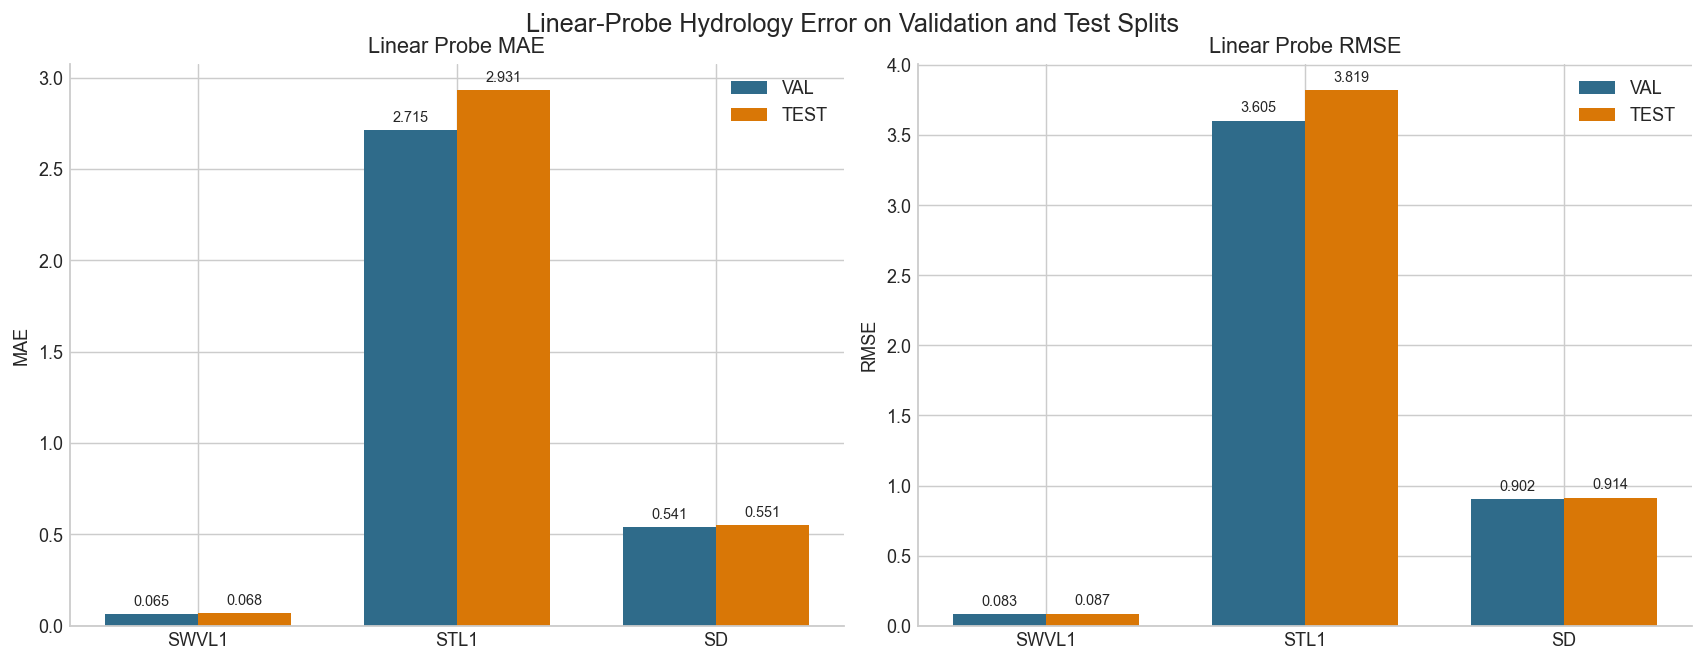

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/linear_probe_val_test_mae_rmse.png


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
colors = {'val': '#2F6B8A', 'test': '#D97706'}
x = np.arange(len(variables))
width = 0.36

for ax, metric_name in zip(axes, ['MAE', 'RMSE']):
    for offset, split in [(-width / 2, 'val'), (width / 2, 'test')]:
        values = [
            headline_df.loc[
                (headline_df['split'] == split) & (headline_df['variable'] == variable),
                metric_name,
            ].iloc[0]
            for variable in variables
        ]
        bars = ax.bar(x + offset, values, width=width, label=split.upper(), color=colors[split])
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

    ax.set_title(f'Linear Probe {metric_name}')
    ax.set_xticks(x)
    ax.set_xticklabels([v.upper() for v in variables])
    ax.set_ylabel(metric_name)
    ax.legend(frameon=False)

fig.suptitle('Linear-Probe Hydrology Error on Validation and Test Splits', fontsize=14, y=1.03)
save_path = FIGURE_DIR / 'linear_probe_val_test_mae_rmse.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


In [56]:
comparison_df = pd.DataFrame({
    'variable': variables,
    'linear_probe_val_mae': [linear_probe_metrics[f'val_{variable}_mae'] for variable in variables],
    'finetuned_val_mae': [stage1_val_metrics[variable] for variable in variables],
})
comparison_df['improvement_factor'] = comparison_df['linear_probe_val_mae'] / comparison_df['finetuned_val_mae']
comparison_df


,variable,linear_probe_val_mae,finetuned_val_mae,improvement_factor
0,swvl1,0.064648,0.012459,5.188973
1,stl1,2.715384,1.050773,2.584178
2,sd,0.540951,0.132759,4.074693


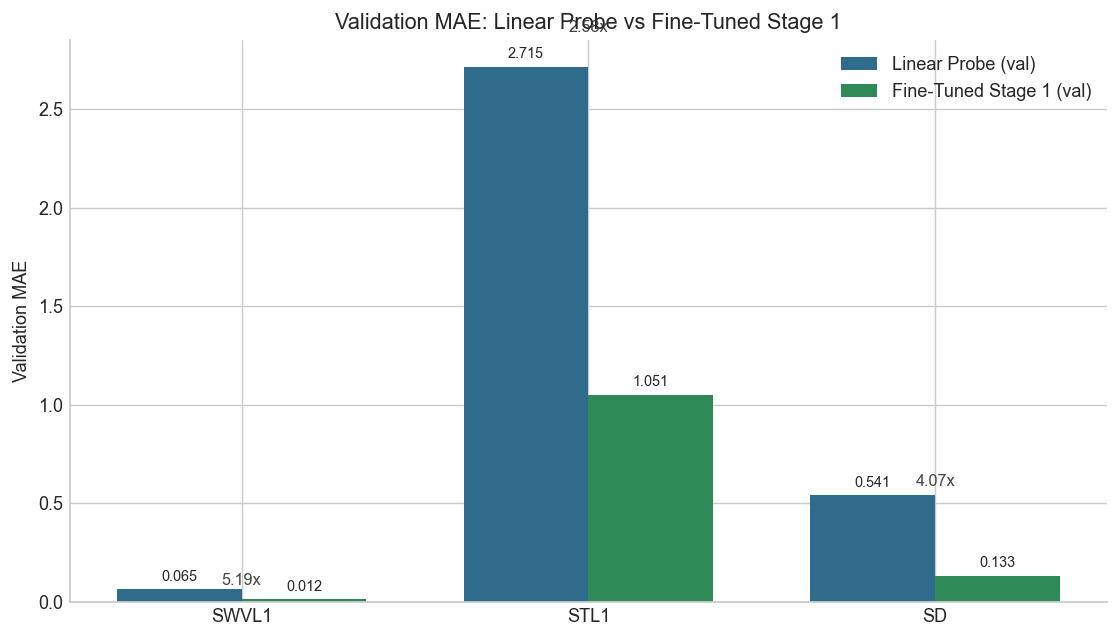

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/linear_probe_vs_finetuned_val_mae.png


In [57]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
x = np.arange(len(variables))
width = 0.36

lp_vals = comparison_df['linear_probe_val_mae'].to_numpy()
ft_vals = comparison_df['finetuned_val_mae'].to_numpy()

bars_lp = ax.bar(x - width / 2, lp_vals, width=width, label='Linear Probe (val)', color='#2F6B8A')
bars_ft = ax.bar(x + width / 2, ft_vals, width=width, label='Fine-Tuned Stage 1 (val)', color='#2E8B57')

ax.bar_label(bars_lp, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars_ft, fmt='%.3f', padding=3, fontsize=8)

for i, factor in enumerate(comparison_df['improvement_factor']):
    y = max(lp_vals[i], ft_vals[i])
    ax.text(i, y * 1.06, f'{factor:.2f}x', ha='center', va='bottom', fontsize=9, color='#444444')

ax.set_xticks(x)
ax.set_xticklabels([v.upper() for v in variables])
ax.set_ylabel('Validation MAE')
ax.set_title('Validation MAE: Linear Probe vs Fine-Tuned Stage 1')
ax.legend(frameon=False)

save_path = FIGURE_DIR / 'linear_probe_vs_finetuned_val_mae.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


## Normalized Error Comparison

The raw MAE comparisons above are useful within a variable, but not across variables because `SWVL1`, `STL1`, and `SD` are measured in different native units. To compare cross-variable difficulty fairly, we normalize MAE by the Stage 1 training standard deviation from `_NEW_VAR_NORM` in [src/finetune_stage1.py](/Users/advitranawade/Penn%20Junior/CIS%207000/CIS-7000-Final-Project/src/finetune_stage1.py).


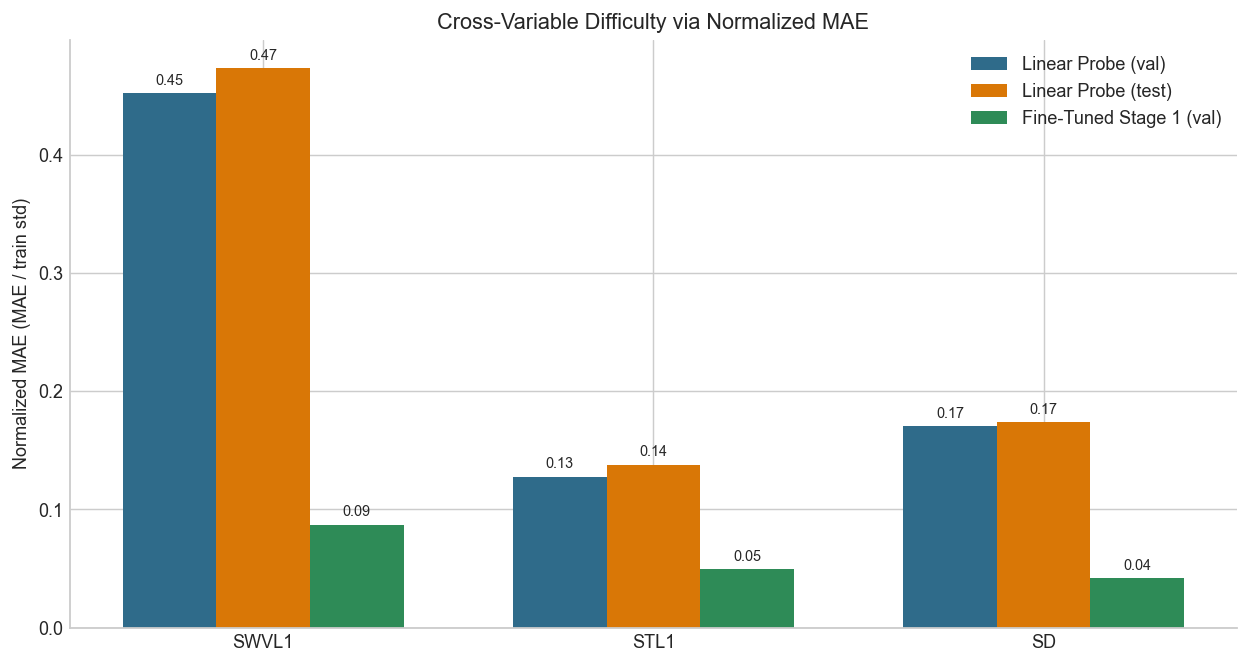

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/normalized_mae_comparison.png


In [58]:
TRAIN_STDS = {'swvl1': 1.428390e-01, 'stl1': 2.123255e+01, 'sd': 3.172587e+00}

normalized_df = pd.DataFrame({
    'variable': variables,
    'linear_probe_val_nmae': [linear_probe_metrics[f'val_{v}_mae'] / TRAIN_STDS[v] for v in variables],
    'linear_probe_test_nmae': [linear_probe_metrics[f'test_{v}_mae'] / TRAIN_STDS[v] for v in variables],
    'finetuned_val_nmae': [stage1_val_metrics[v] / TRAIN_STDS[v] for v in variables],
})
normalized_df

fig, ax = plt.subplots(figsize=(9.5, 5), constrained_layout=True)
x = np.arange(len(variables))
width = 0.24
bars1 = ax.bar(x - width, normalized_df['linear_probe_val_nmae'], width=width, label='Linear Probe (val)', color='#2F6B8A')
bars2 = ax.bar(x, normalized_df['linear_probe_test_nmae'], width=width, label='Linear Probe (test)', color='#D97706')
bars3 = ax.bar(x + width, normalized_df['finetuned_val_nmae'], width=width, label='Fine-Tuned Stage 1 (val)', color='#2E8B57')
for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([v.upper() for v in variables])
ax.set_ylabel('Normalized MAE (MAE / train std)')
ax.set_title('Cross-Variable Difficulty via Normalized MAE')
ax.legend(frameon=False)
save_path = FIGURE_DIR / 'normalized_mae_comparison.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


## Spatial Error Maps

These plots use the saved spatial aggregates from evaluation. For each hydrology variable, validation and test maps are shown side by side so you can compare where the linear probe is consistently strong or weak. The rendering below uses a north-up orientation and percentile-based color scaling so regional differences are easier to see without being washed out by a few extreme cells.


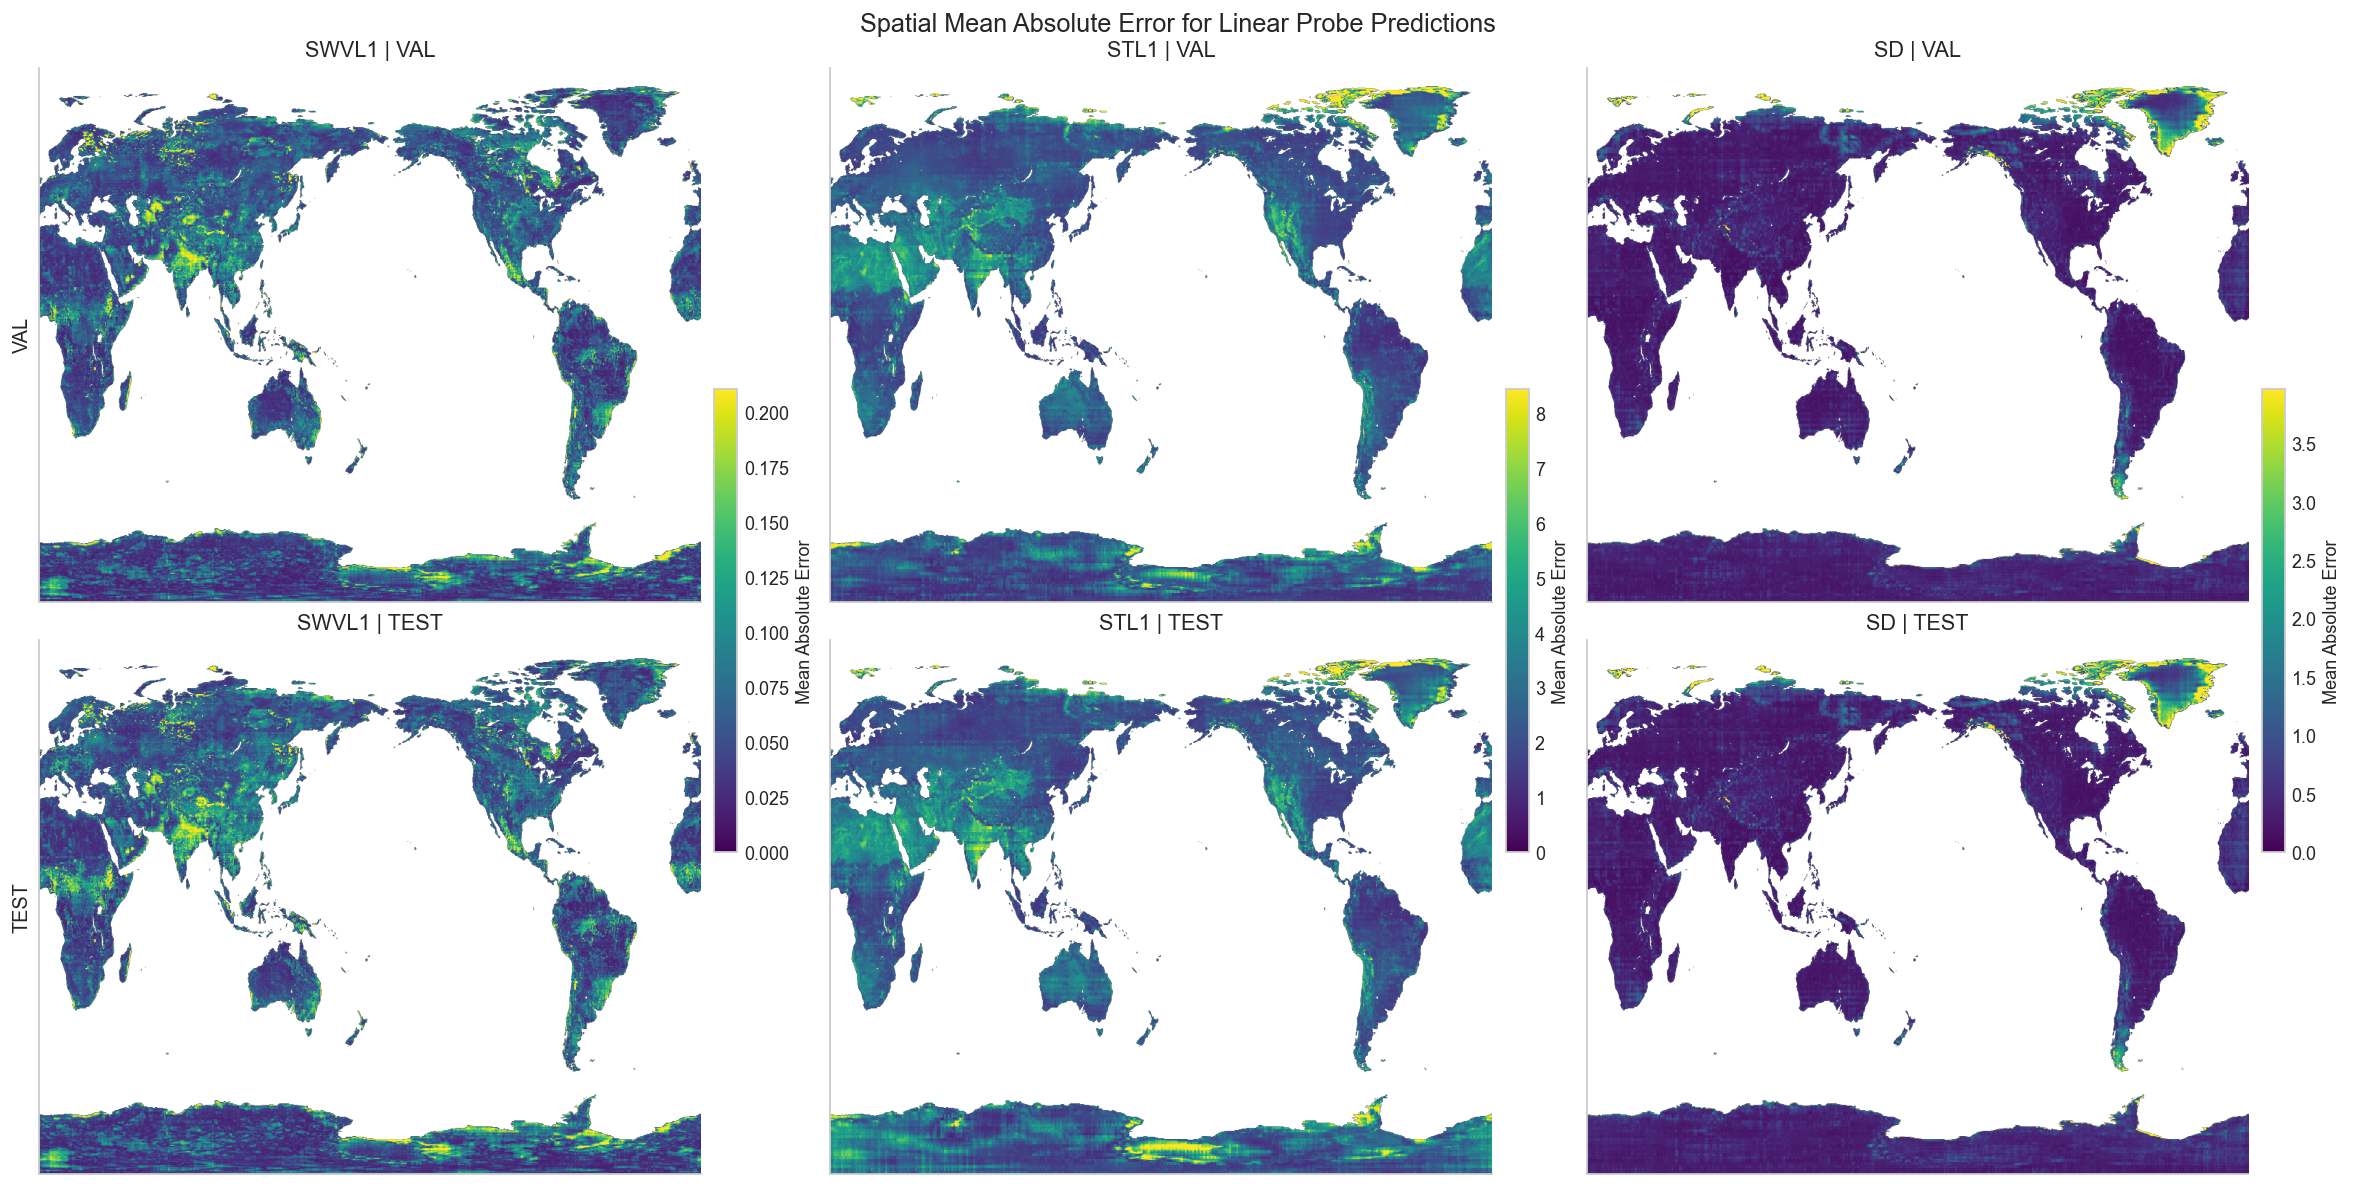

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/spatial_mean_abs_err.png


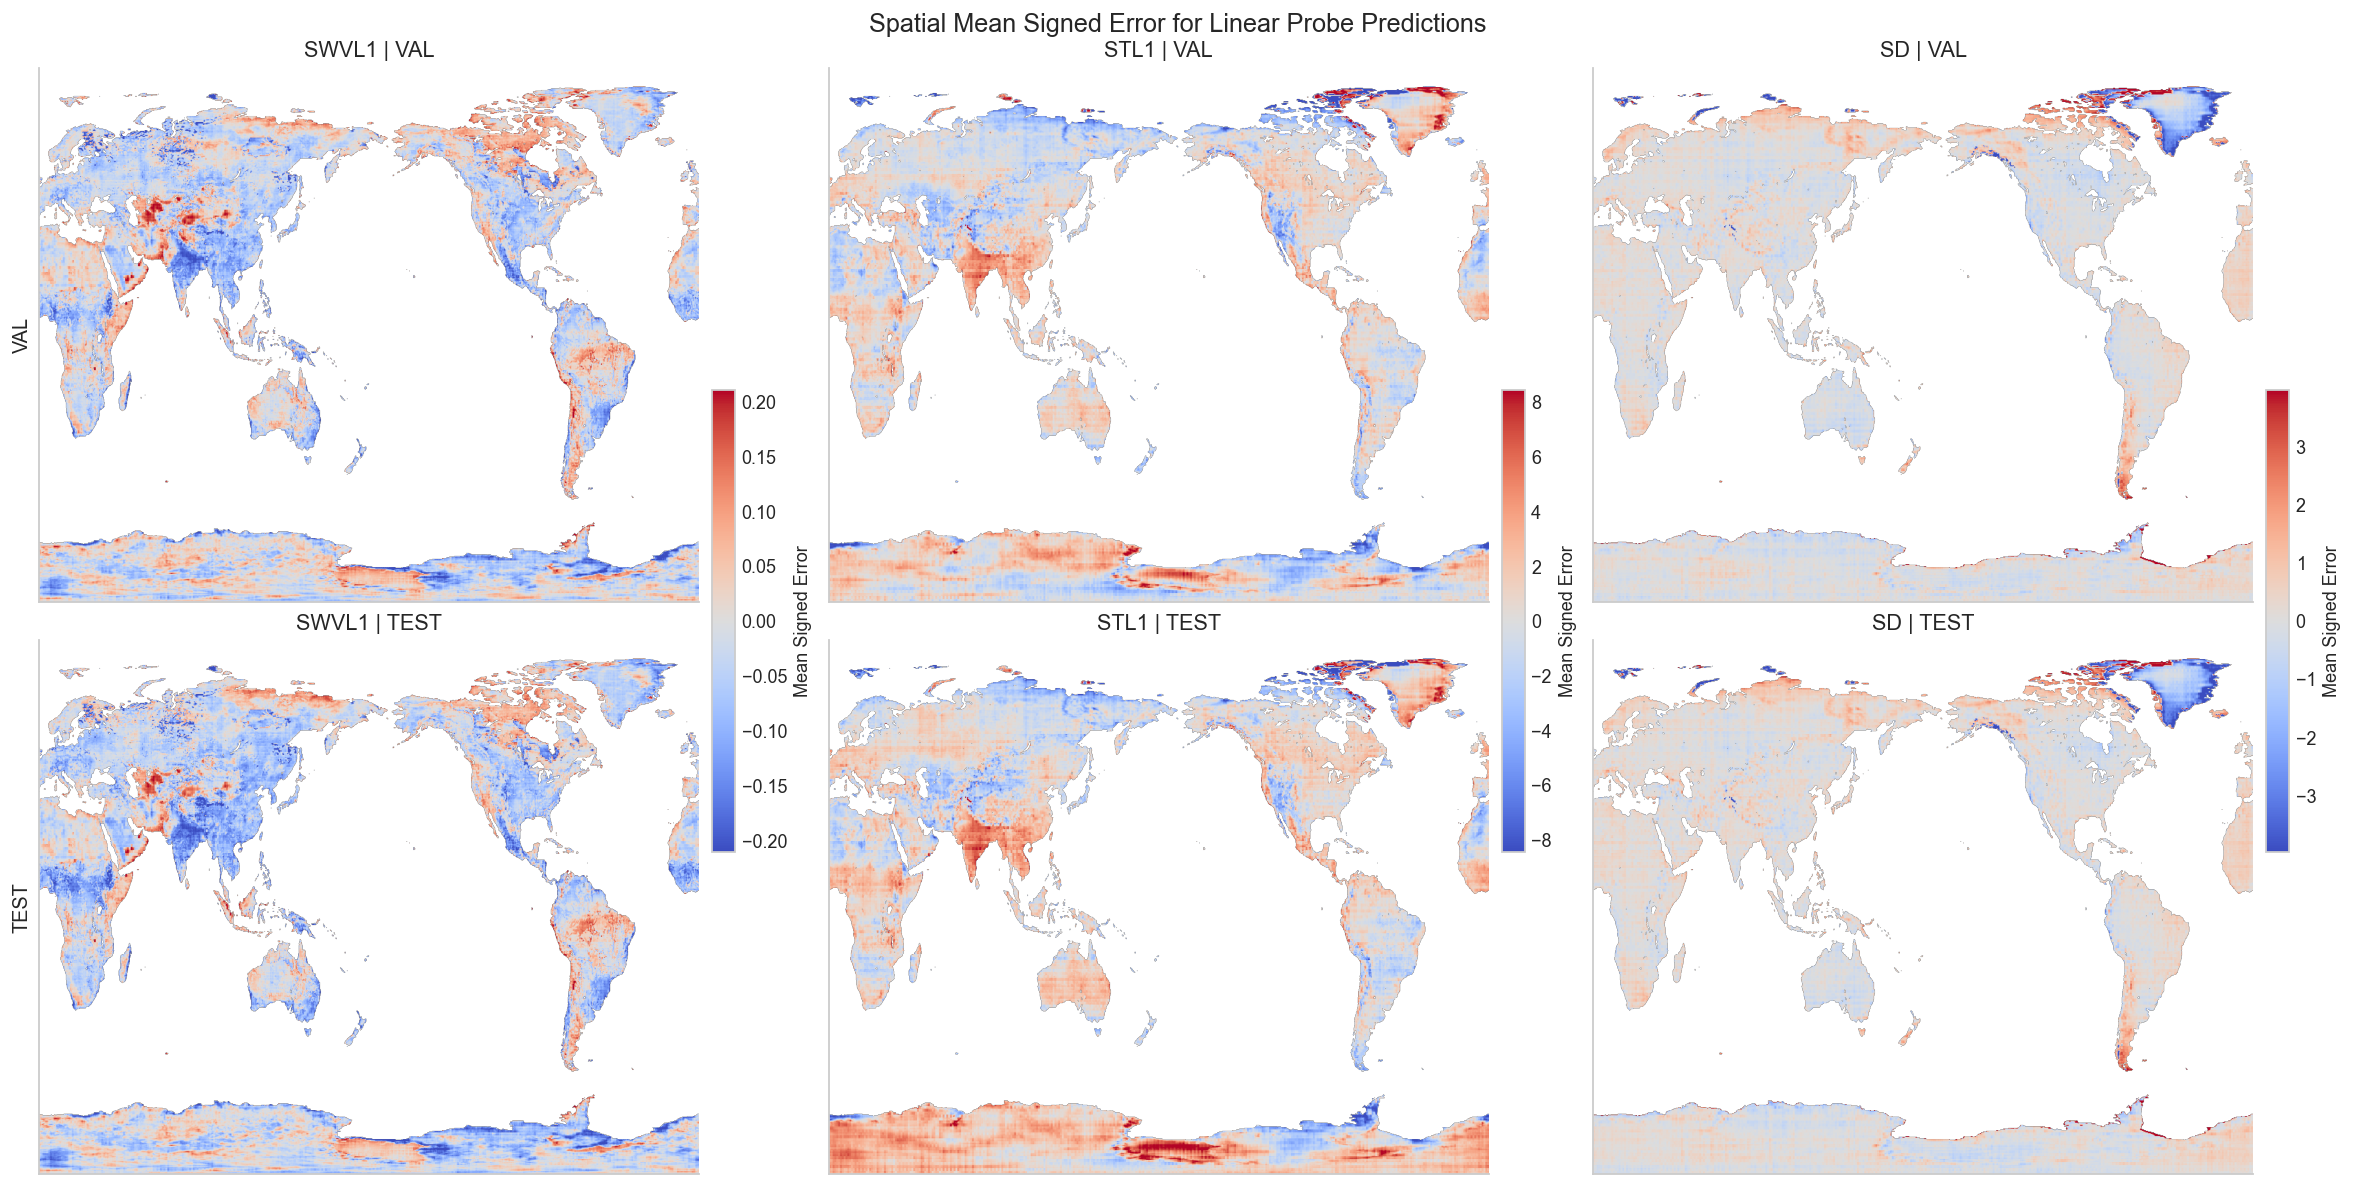

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/spatial_mean_signed_err.png


In [59]:
SPATIAL_DIR = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'spatial_aggregates'

count_maps = {
    split: np.load(SPATIAL_DIR / f'{split}_count.npy')
    for split in ['val', 'test']
}

spatial_metrics = {}
for split in ['val', 'test']:
    spatial_metrics[split] = {}
    for variable in variables:
        spatial_metrics[split][variable] = {
            'mean_abs_err': np.load(SPATIAL_DIR / f'{split}_{variable}_mean_abs_err.npy'),
            'mean_signed_err': np.load(SPATIAL_DIR / f'{split}_{variable}_mean_signed_err.npy'),
            'rmse': np.load(SPATIAL_DIR / f'{split}_{variable}_rmse.npy'),
        }

def masked_land_map(array, split):
    return np.ma.masked_where(count_maps[split] <= 0, array)

def finite_values(masked_array):
    return masked_array.compressed()

pretty_names = {'swvl1': 'SWVL1', 'stl1': 'STL1', 'sd': 'SD'}

for metric_key, title, cmap, symmetric in [
    ('mean_abs_err', 'Mean Absolute Error', 'viridis', False),
    ('mean_signed_err', 'Mean Signed Error', 'coolwarm', True),
]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8.8), constrained_layout=True)
    for col, variable in enumerate(variables):
        maps = {
            split: masked_land_map(spatial_metrics[split][variable][metric_key], split)
            for split in ['val', 'test']
        }

        if symmetric:
            vmax = max(
                float(np.quantile(np.abs(finite_values(maps['val'])), 0.99)),
                float(np.quantile(np.abs(finite_values(maps['test'])), 0.99)),
            )
            vmin = -vmax
        else:
            vmax = max(
                float(np.quantile(finite_values(maps['val']), 0.99)),
                float(np.quantile(finite_values(maps['test']), 0.99)),
            )
            vmin = 0.0

        for row, split in enumerate(['val', 'test']):
            ax = axes[row, col]
            im = ax.imshow(maps[split], cmap=cmap, origin='upper', vmin=vmin, vmax=vmax, aspect='auto')
            ax.set_title(f"{pretty_names[variable]} | {split.upper()}")
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(split.upper(), fontsize=11)

        cbar = fig.colorbar(im, ax=axes[:, col], fraction=0.035, pad=0.02)
        cbar.ax.set_ylabel(title, rotation=90)

    fig.suptitle(f'Spatial {title} for Linear Probe Predictions', fontsize=14, y=1.02)
    save_path = FIGURE_DIR / f'spatial_{metric_key}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)


## Spatial Discussion

- **Validation and test look very similar spatially**, which supports the earlier aggregate-metric conclusion that the linear probe is generalizing rather than overfitting to one season-year combination.
- **SWVL1 errors are broad and diffuse**, with elevated error across many humid and high-latitude land regions rather than being confined to a single hotspot. That is consistent with soil moisture being the hardest target to decode from atmospheric-only latent information.
- **STL1 shows stronger localized structure**, especially in high-latitude and coastal transition regions. The signed-error maps suggest broad, low-frequency bias patterns rather than purely random noise, which means the frozen latent contains relevant temperature information but the linear head cannot fully correct regional calibration differences.
- **SD errors are sparse and geographically concentrated**, with most land pixels near zero and larger error concentrated in snow-dominated regions. This is a good sign scientifically: the probe is not failing everywhere, but rather where snow processes are most nonlinear and seasonally sensitive.
- Across all three variables, the **signed-error maps are smoother than the absolute-error maps**, which suggests there are coherent regional biases layered on top of local variation. That makes a strong qualitative case for why Stage 1 fine-tuning helps: it is likely learning regional adjustments that a single frozen linear readout cannot express.


## Time-Series Error Curves

The per-sample CSV lets us track how aggregate land error evolves over time. These plots help answer whether the probe is failing uniformly or whether there are specific periods with elevated difficulty.


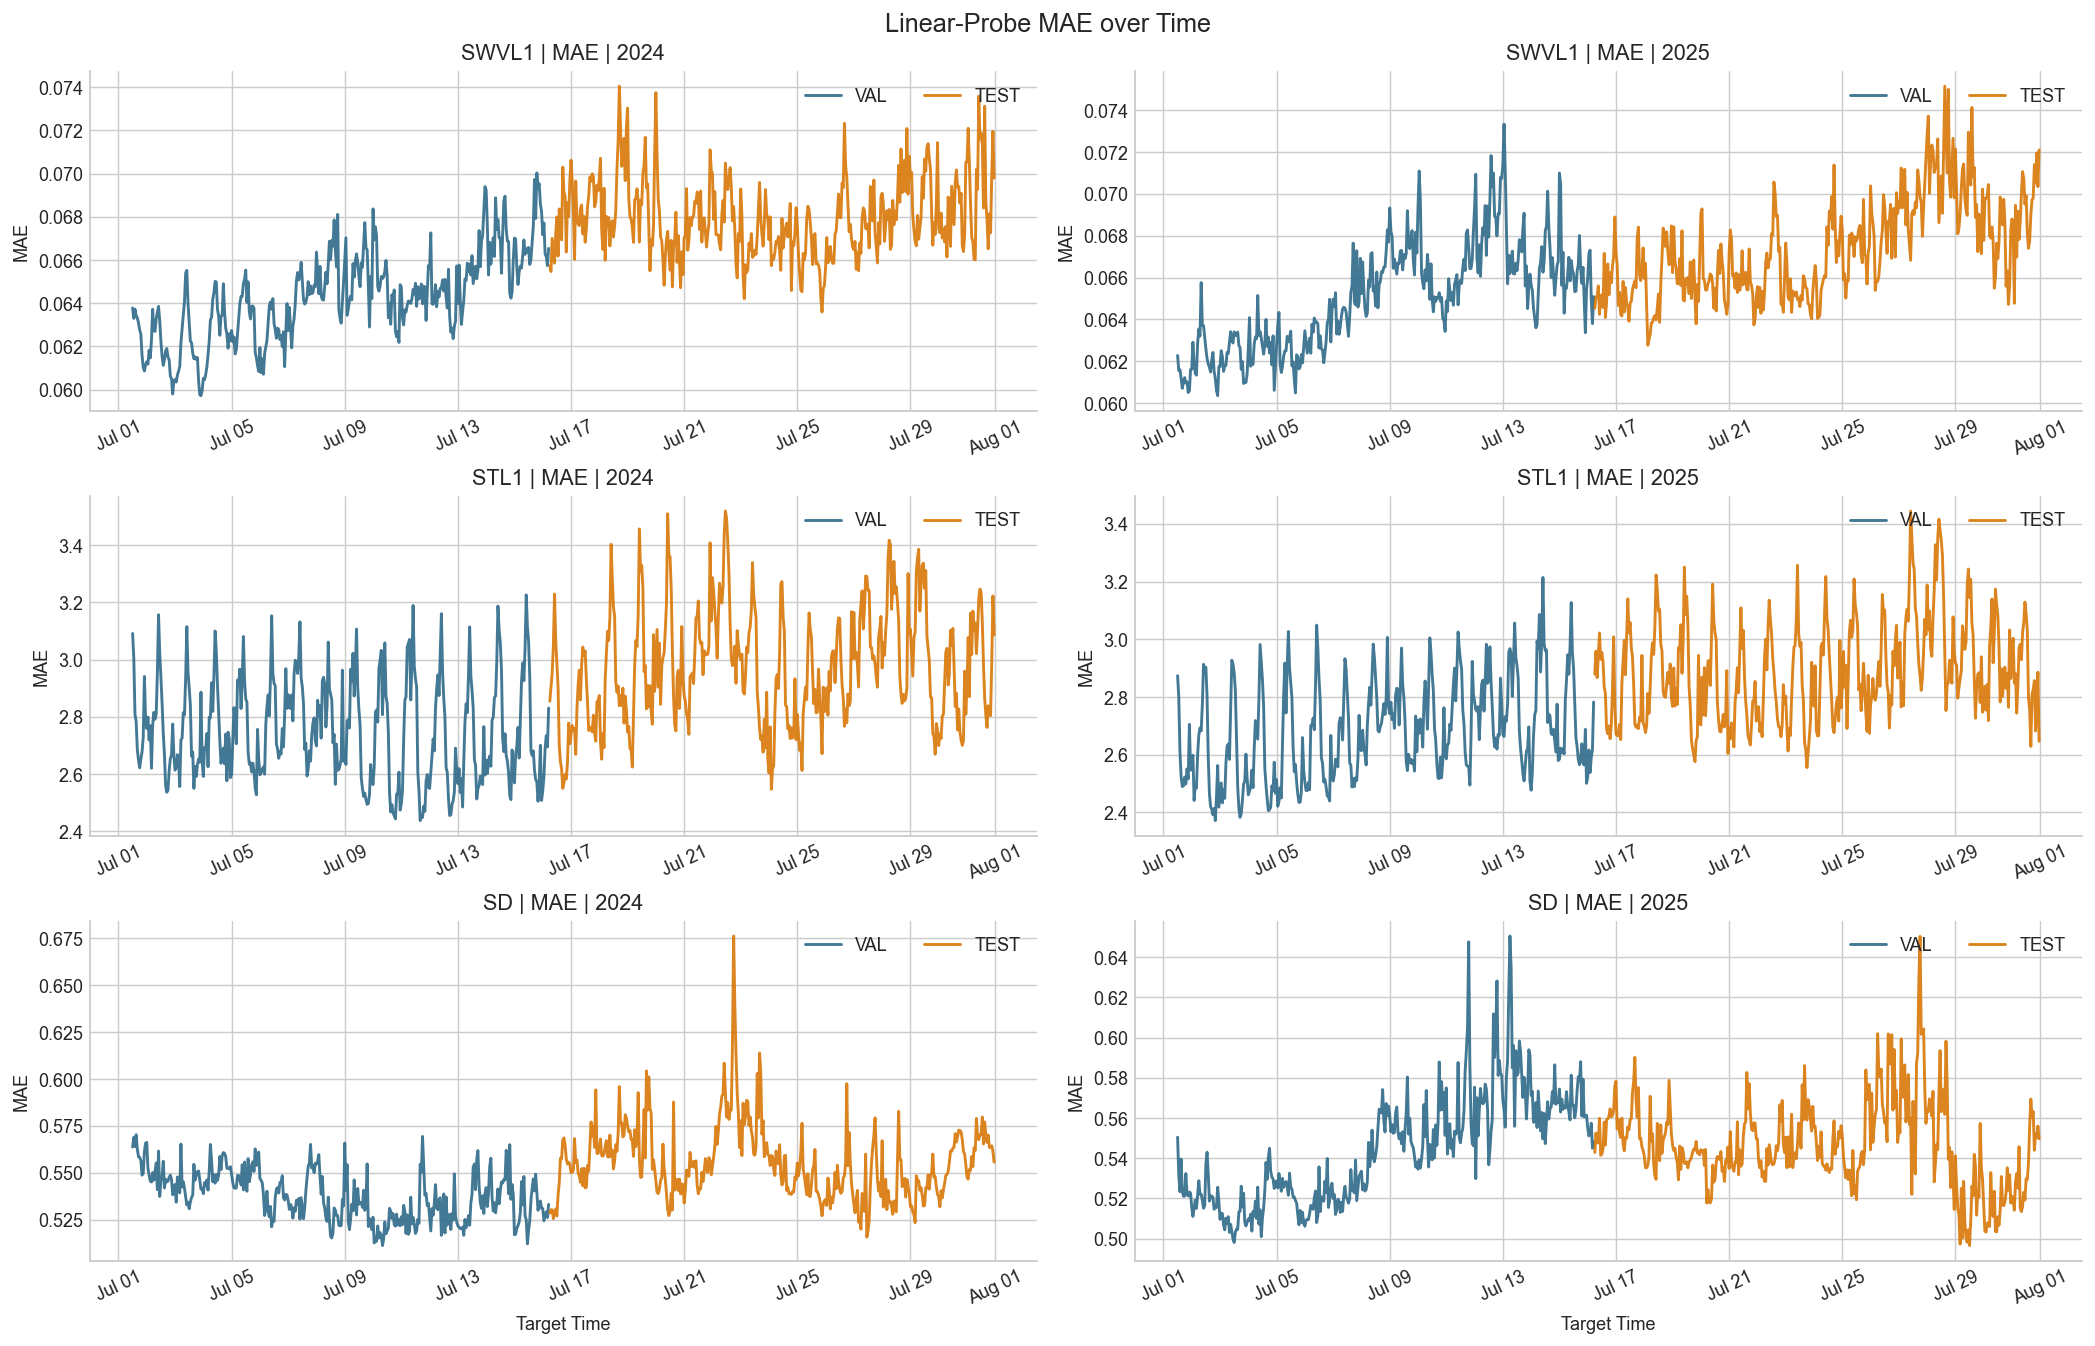

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/timeseries_mae.png


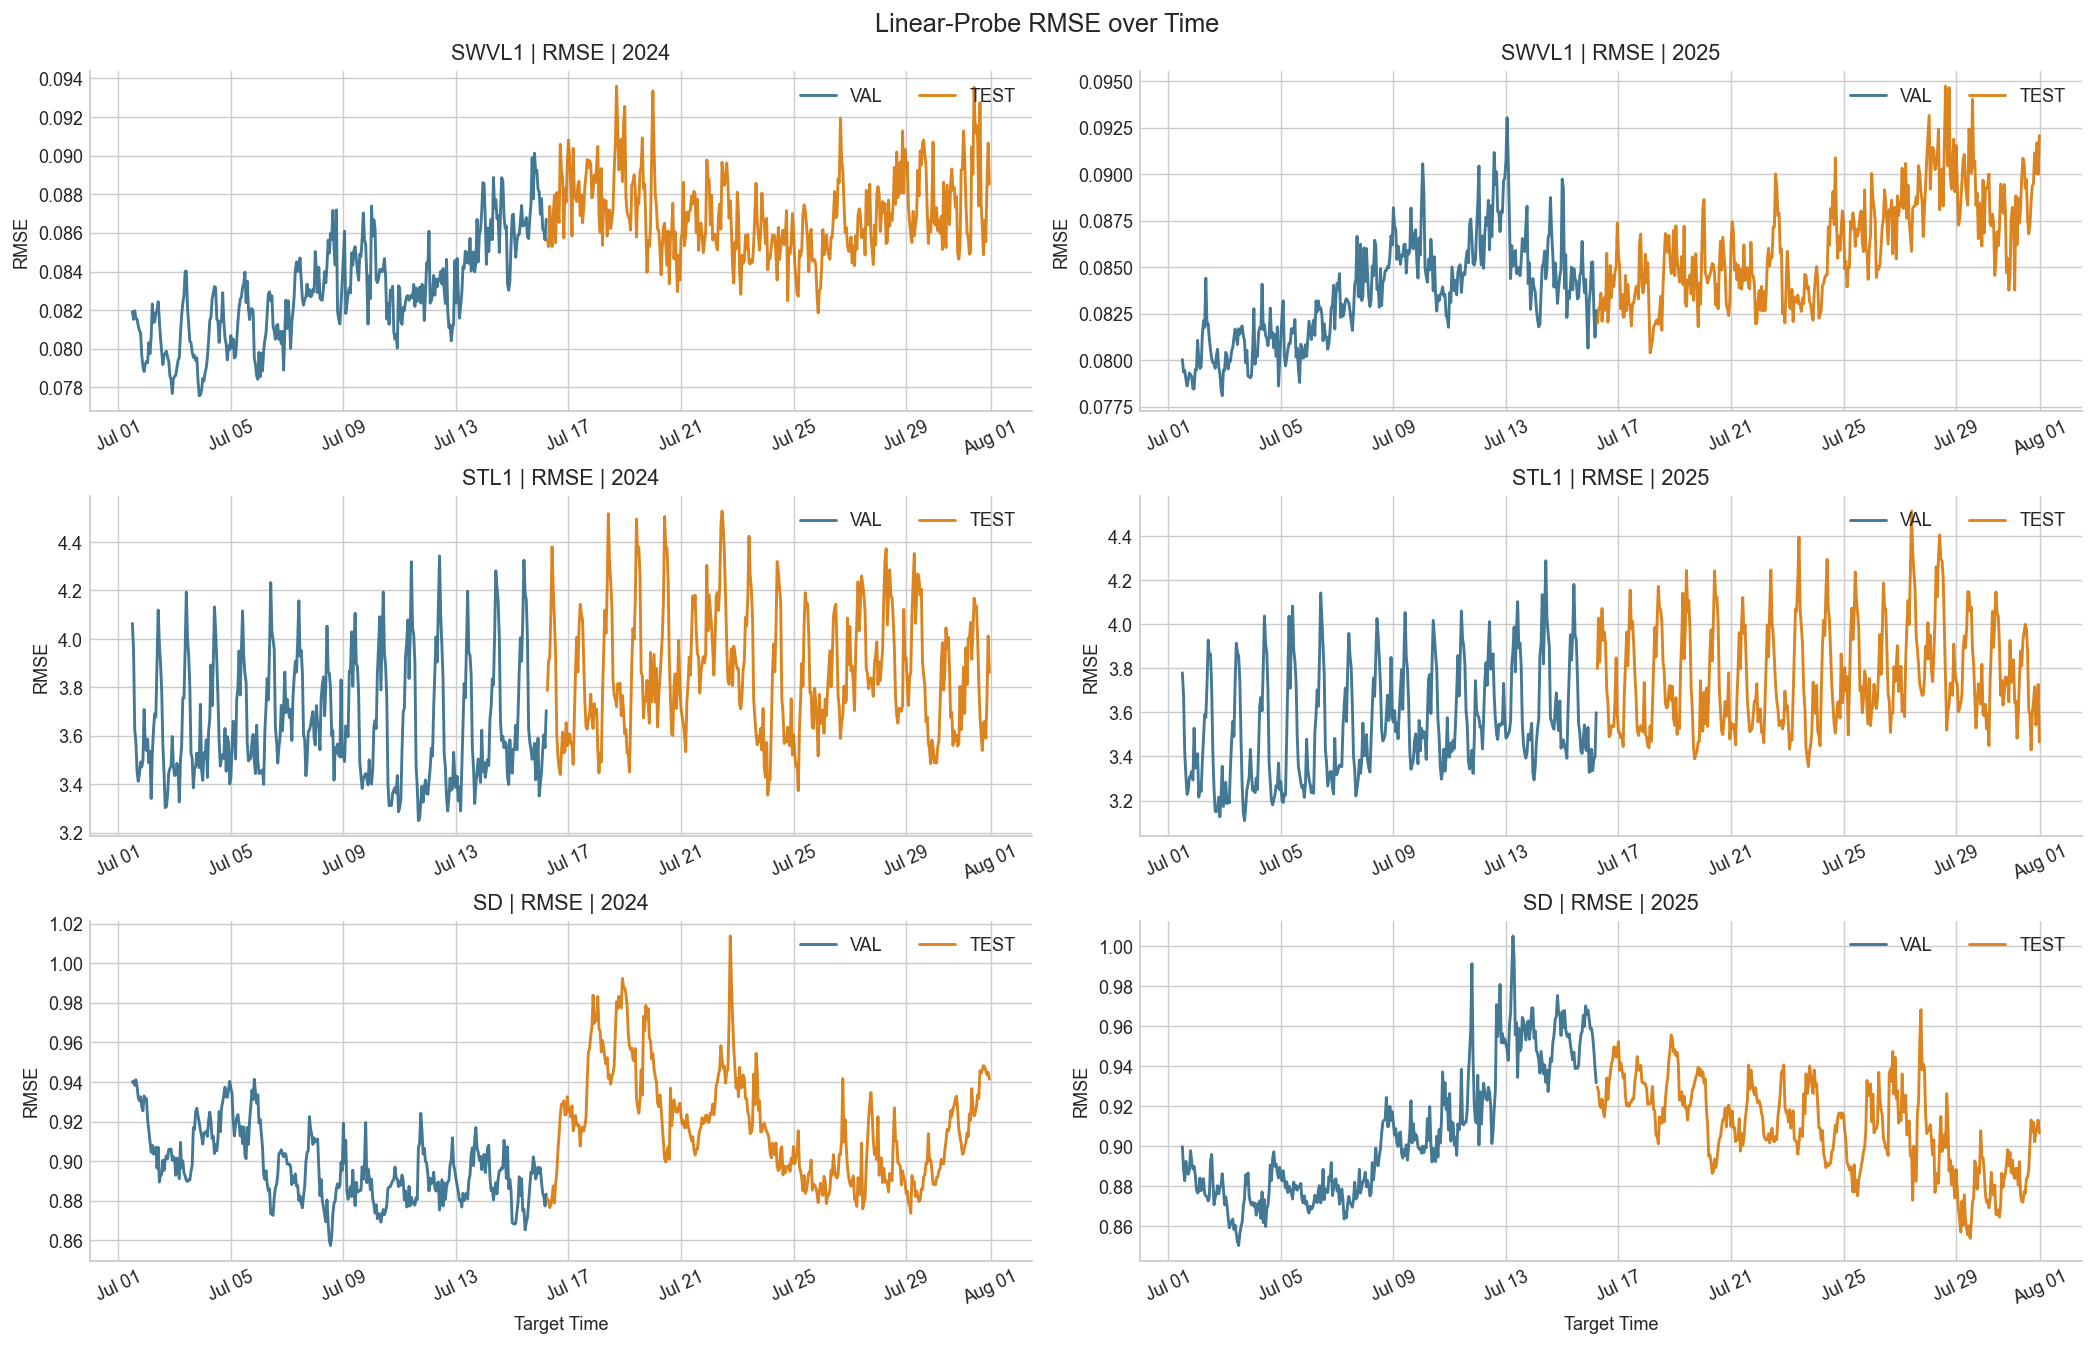

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/timeseries_rmse.png


mae                                    rmse            \
                      mean       std       min       max      mean       std   
split target_var                                                               
test  sd          0.551010  0.021076  0.496620  0.676316  0.913993  0.025176   
      stl1        2.930501  0.189045  2.546775  3.519206  3.811719  0.240724   
      swvl1       0.067672  0.002093  0.062762  0.075151  0.086583  0.002479   
val   sd          0.540951  0.021706  0.498151  0.650455  0.901748  0.027271   
      stl1        2.715384  0.173701  2.371682  3.226179  3.596127  0.246880   
      swvl1       0.064648  0.002327  0.059722  0.073333  0.083246  0.002693   

                                     mean_signed_error                      \
                       min       max              mean       std       min   
split target_var                                                             
test  sd          0.853836  1.013825          0.069622  0.085754 -0.168986   
      stl1        3.353852  4.527686          0.705694  0.568814 -1.009093   
      swvl1       0.080394  0.094742         -0.024955  0.008013 -0.047087   
val   sd          0.850294  1.005009          0.029923  0.101318 -0.263420   
      stl1        3.108713  4.342420          0.101691  0.532308 -1.410036   
      swvl1       0.077573  0.093043         -0.015129  0.009042 -0.041107   

                            
                       max  
split target_var            
test  sd          0.358785  
      stl1        2.304645  
      swvl1       0.000557  
val   sd          0.380088  
      stl1        1.446846  
      swvl1       0.014868

In [60]:
PER_SAMPLE_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'per_sample_metrics.csv'
import matplotlib.dates as mdates

per_sample_df = pd.read_csv(PER_SAMPLE_PATH)
per_sample_df['target_time'] = pd.to_datetime(per_sample_df['target_time'])
per_sample_df['source_time'] = pd.to_datetime(per_sample_df['source_time'])
per_sample_df['target_year'] = per_sample_df['target_time'].dt.year

ts_df = per_sample_df.sort_values(['target_var', 'split', 'target_time']).copy()
years = [2024, 2025]

for metric_name, ylabel in [('mae', 'MAE'), ('rmse', 'RMSE')]:
    fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=False, constrained_layout=True)
    for row, variable in enumerate(variables):
        var_df = ts_df[ts_df['target_var'] == variable]
        for col, year in enumerate(years):
            ax = axes[row, col]
            year_df = var_df[var_df['target_year'] == year]
            for split, color in [('val', '#2F6B8A'), ('test', '#D97706')]:
                split_df = year_df[year_df['split'] == split].sort_values('target_time')
                if split_df.empty:
                    continue
                ax.plot(
                    split_df['target_time'],
                    split_df[metric_name],
                    label=split.upper(),
                    color=color,
                    linewidth=1.6,
                    alpha=0.9,
                )
            ax.set_title(f"{pretty_names[variable]} | {ylabel} | {year}")
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax.tick_params(axis='x', rotation=25)
            ax.legend(frameon=False, ncol=2, loc='upper right')

    for ax in axes[-1, :]:
        ax.set_xlabel('Target Time')
    fig.suptitle(f'Linear-Probe {ylabel} over Time', fontsize=14, y=1.02)
    save_path = FIGURE_DIR / f'timeseries_{metric_name}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

time_summary = (
    ts_df.groupby(['split', 'target_var'])[['mae', 'rmse', 'mean_signed_error']]
    .agg(['mean', 'std', 'min', 'max'])
)
time_summary


## Hour-of-Day MAE

To separate slow seasonal drift from within-day structure, we can aggregate the per-sample CSV by target hour. This makes the strong diurnal behavior of `STL1` explicit.


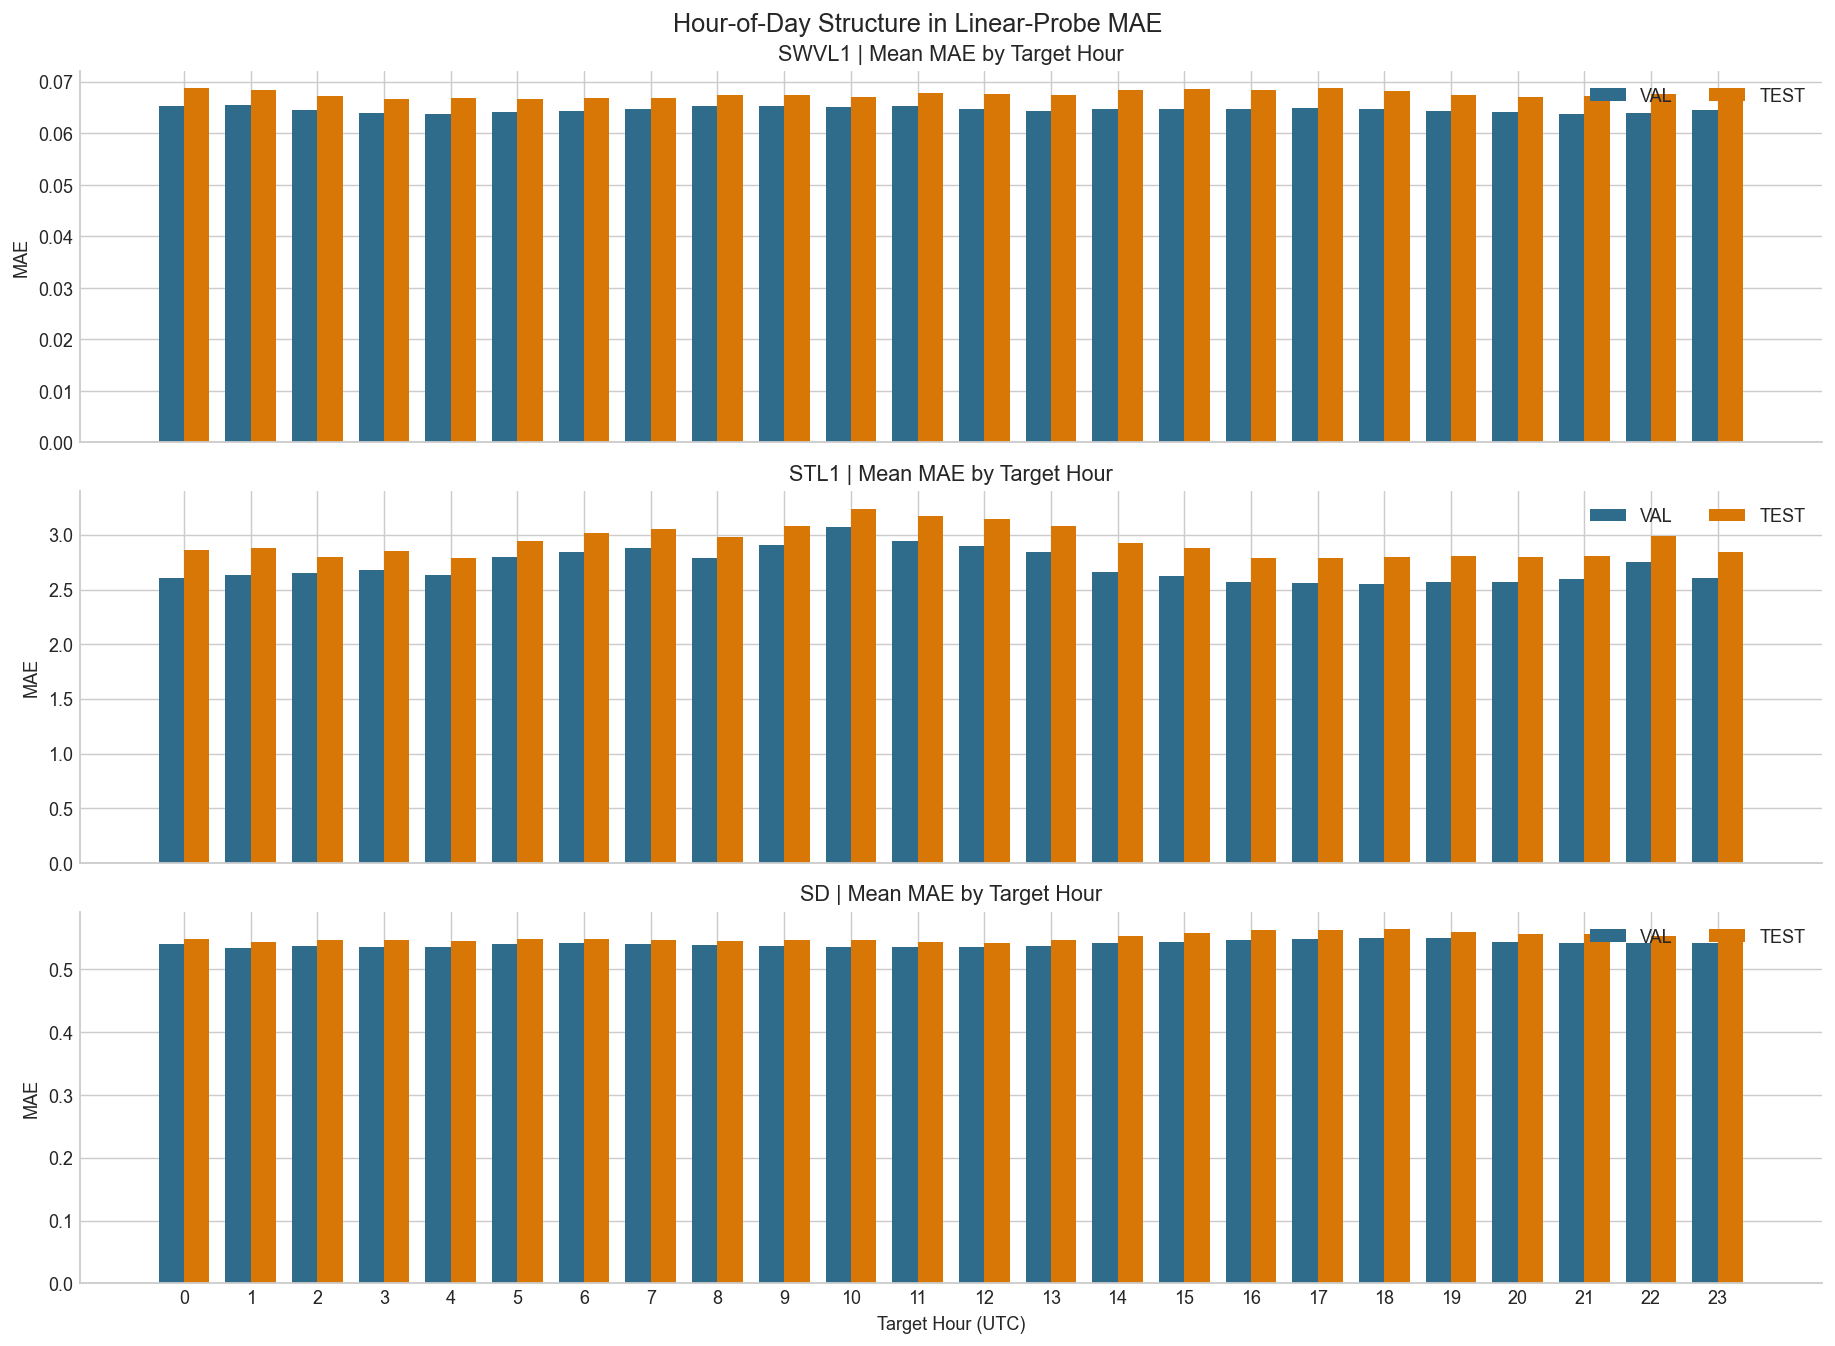

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/hour_of_day_mae.png


In [61]:
hourly_df = ts_df.copy()
hourly_df['hour'] = hourly_df['target_time'].dt.hour
hourly_mae = hourly_df.groupby(['target_var', 'split', 'hour'], as_index=False)['mae'].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
hours = np.arange(24)
width = 0.38
for ax, variable in zip(axes, variables):
    sub = hourly_mae[hourly_mae['target_var'] == variable]
    val_vals = sub[sub['split'] == 'val'].set_index('hour').reindex(hours)['mae'].to_numpy()
    test_vals = sub[sub['split'] == 'test'].set_index('hour').reindex(hours)['mae'].to_numpy()
    ax.bar(hours - width / 2, val_vals, width=width, label='VAL', color='#2F6B8A')
    ax.bar(hours + width / 2, test_vals, width=width, label='TEST', color='#D97706')
    ax.set_title(f"{pretty_names[variable]} | Mean MAE by Target Hour")
    ax.set_ylabel('MAE')
    ax.legend(frameon=False, ncol=2, loc='upper right')
axes[-1].set_xlabel('Target Hour (UTC)')
axes[-1].set_xticks(hours)
fig.suptitle('Hour-of-Day Structure in Linear-Probe MAE', fontsize=14, y=1.02)
save_path = FIGURE_DIR / 'hour_of_day_mae.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


## Temporal Discussion

- **The validation and test curves stay on the same overall scale in both years**, which supports the aggregate-metric result that the linear probe generalizes reasonably well rather than failing catastrophically once it leaves the validation window.
- **SWVL1 shows a gradual upward drift through July in both MAE and RMSE**, especially toward late July. That suggests soil-moisture prediction becomes harder as summer progresses, which fits the intuition that atmospheric-only latent information is less sufficient for recovering accumulated land-water state under sustained drying or evolving surface conditions.
- **STL1 has a clear diurnal cycle rather than a vague synoptic oscillation**. In the hour-of-day plot, MAE peaks around `09–12 UTC` at roughly `3.0 K` and bottoms out around `18–03 UTC` near `2.68 K`, a swing of about `17%` relative to the mean. This is consistent with the daily heating cycle: the frozen latent captures broad soil-temperature structure, but the linear head cannot fully invert the nonlinear near-surface thermal response when temperatures are evolving fastest.
- **SWVL1 and SD are much flatter by hour of day**. Their hour-of-day amplitude is only about `3%` of the mean, so most of the visible variation there is slow drift or episodic events rather than a strong daily cycle.
- **SD is comparatively stable most of the time, but punctuated by episodic bursts of error**, particularly in mid-to-late July. That matches the spatial maps: snow depth is not uniformly difficult everywhere, but certain periods and regions create localized failures that stand out against an otherwise lower-error background.
- Across all three targets, **test is usually slightly worse than validation but not dramatically so**. The gap is systematic rather than explosive, which strengthens the interpretation that frozen Aurora latents do carry real hydrology information, just not enough to match the much stronger fine-tuned model.


## Predicted-vs-Truth Scatter Plots

These panels use the saved subsampled `(prediction, truth)` pairs from evaluation. They are useful for spotting calibration bias, regression-to-the-mean behavior, and whether the probe preserves the full dynamic range of each target variable.


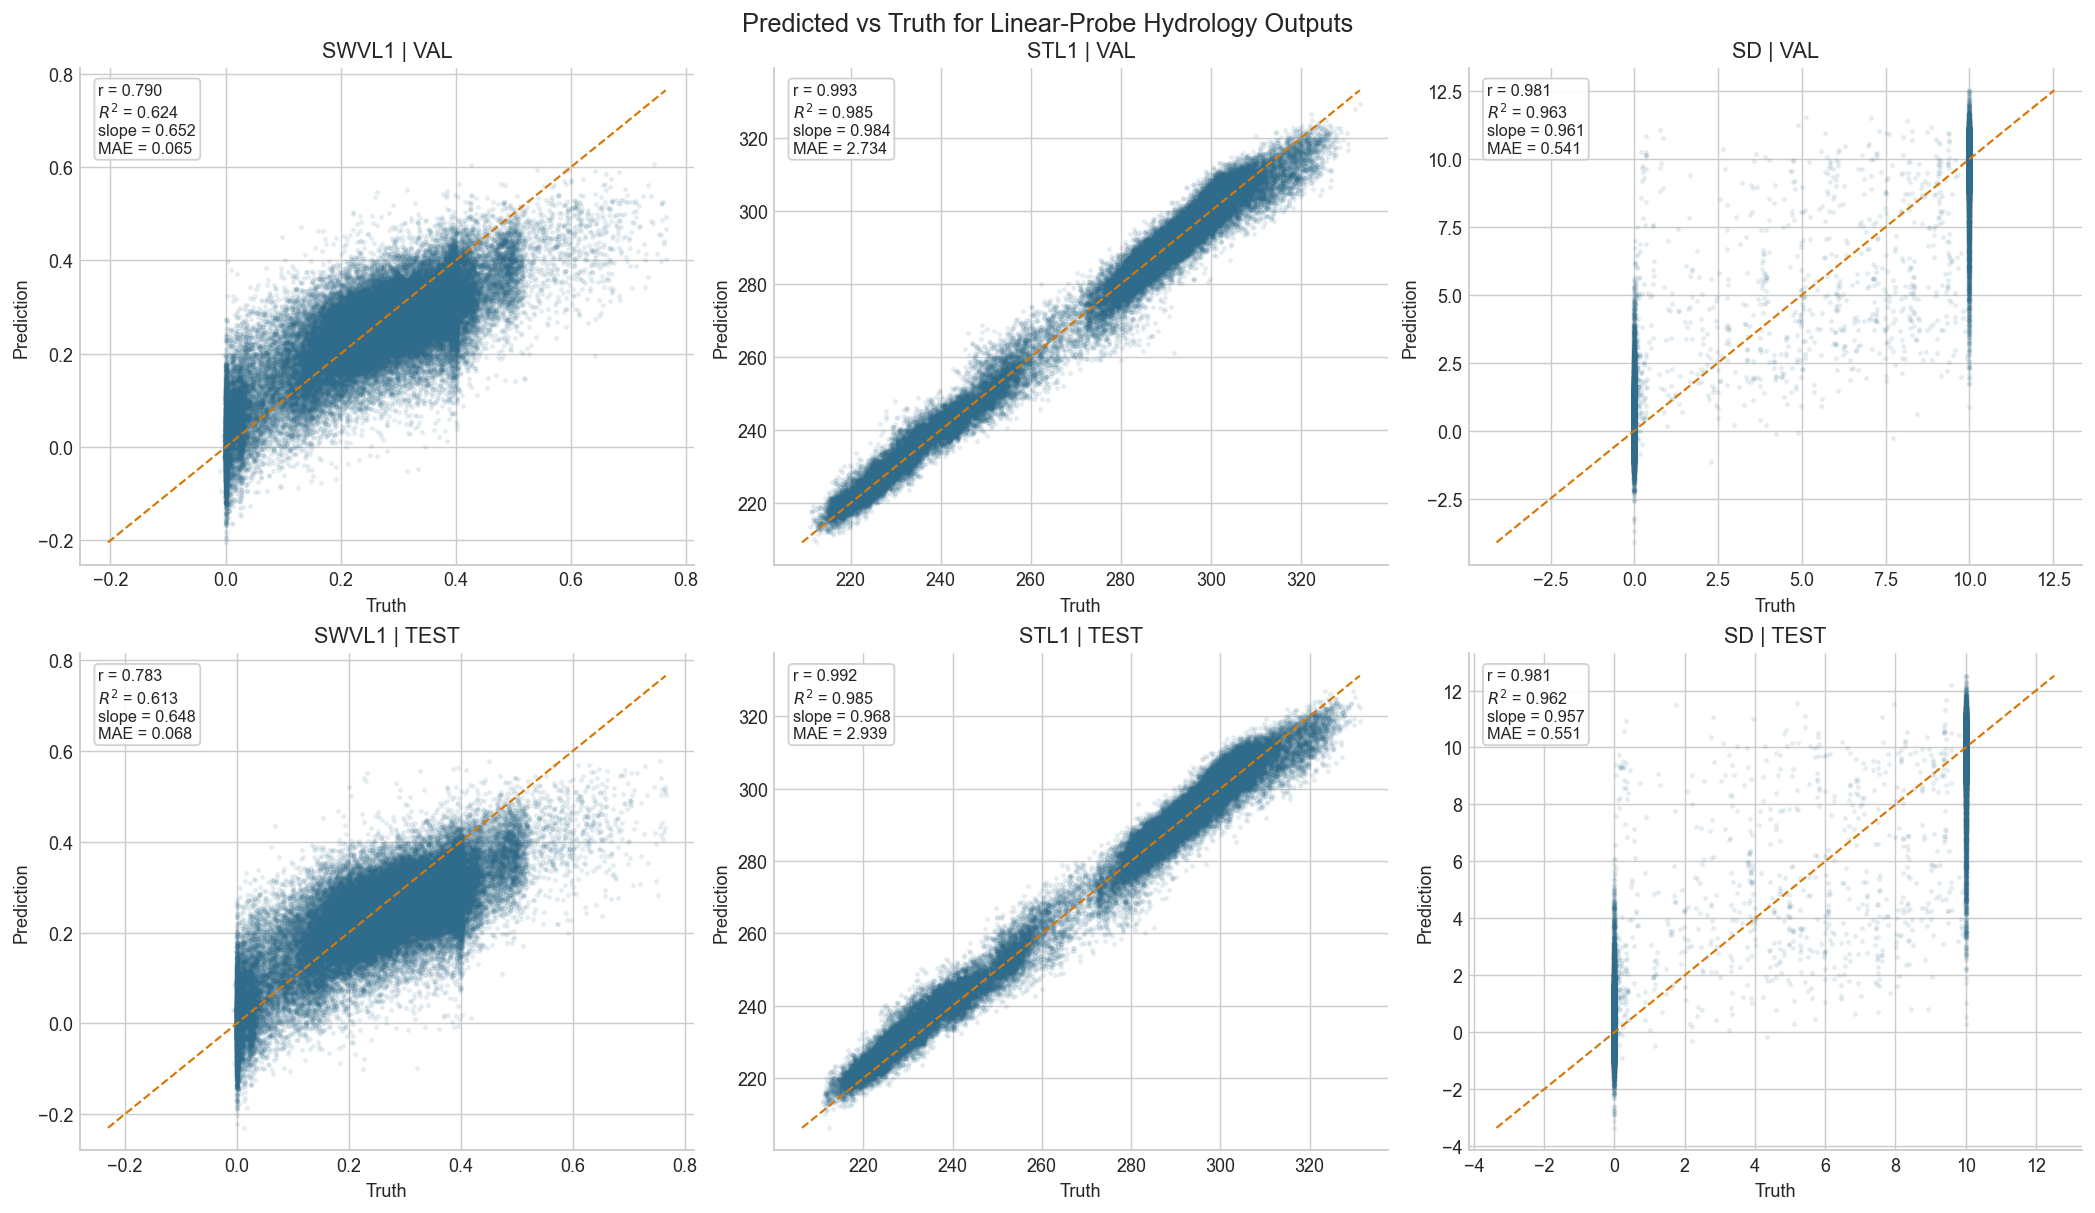

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/scatter_pred_vs_truth.png


In [62]:
import pickle
import zipfile

def load_scatter_payload(path):
    with zipfile.ZipFile(path, 'r') as zf:
        data_name = [name for name in zf.namelist() if name.endswith('data.pkl')][0]
        return pickle.loads(zf.read(data_name))

scatter_payloads = {
    'val': load_scatter_payload(REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'scatter_samples_val.pt'),
    'test': load_scatter_payload(REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'scatter_samples_test.pt'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for row, split in enumerate(['val', 'test']):
    for col, variable in enumerate(variables):
        ax = axes[row, col]
        truth = scatter_payloads[split][variable]['truth']
        pred = scatter_payloads[split][variable]['pred']

        ax.scatter(truth, pred, s=4, alpha=0.08, color='#2F6B8A', rasterized=True)
        lo = float(min(truth.min(), pred.min()))
        hi = float(max(truth.max(), pred.max()))
        ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1.2, color='#D97706')

        corr = float(np.corrcoef(truth, pred)[0, 1])
        r2 = corr ** 2
        slope = float(np.polyfit(truth, pred, 1)[0])
        mae = float(np.mean(np.abs(pred - truth)))
        ax.text(
            0.03,
            0.97,
            f'r = {corr:.3f}\n$R^2$ = {r2:.3f}\nslope = {slope:.3f}\nMAE = {mae:.3f}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.8', alpha=0.9),
        )

        ax.set_title(f"{pretty_names[variable]} | {split.upper()}")
        ax.set_xlabel('Truth')
        ax.set_ylabel('Prediction')

fig.suptitle('Predicted vs Truth for Linear-Probe Hydrology Outputs', fontsize=14, y=1.02)
save_path = FIGURE_DIR / 'scatter_pred_vs_truth.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


## Scatter Discussion

- **`STL1` is the cleanest linear-decoding result by far**. The point cloud is narrow, closely aligned with the `y=x` line, and remains that way on both validation and test. This supports the idea that soil temperature is already strongly encoded in the frozen latent and mostly needs a calibrated readout.
- **`SWVL1` is clearly decodable, but with visible regression-to-the-mean**. Low true values are overpredicted and high true values are underpredicted, so the linear head compresses the dynamic range even though the overall relationship is still strong. That is exactly the kind of limitation we would expect from a strict frozen-feature linear probe.
- **`SD` needs a more careful interpretation than “bad scatter”**. Snow depth is heavily zero-inflated in summer and has a heavy tail that reaches the high-snow regime, so the truth distribution itself is highly non-Gaussian. The probe still achieves a very strong fit in aggregate, but much of that comes from separating broad snow/no-snow regimes. Within those regimes there is still residual scatter, and the negative predictions near zero show a calibration issue on snow-free pixels.
- **Validation and test look nearly identical in all three panels**, which again argues that the main limitation here is representational rather than overfitting of the probe itself.
